In [68]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

In [69]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import GridSearchCV ,RandomizedSearchCV
from sklearn.svm import SVC

In [70]:
Pumpkin_Seeds = pd.read_excel(r"C:\Users\User\Downloads\Pumpkin_Seeds_Dataset.xlsx")
Pumpkin_Seeds

,Area,Perimeter,Major_Axis_Length,Minor_Axis_Length,Convex_Area,Equiv_Diameter,Eccentricity,Solidity,Extent,Roundness,Aspect_Ration,Compactness,Class
0,56276,888.242,326.1485,220.2388,56831,267.6805,0.7376,0.9902,0.7453,0.8963,1.4809,0.8207,Çerçevelik
1,76631,1068.146,417.1932,234.2289,77280,312.3614,0.8275,0.9916,0.7151,0.8440,1.7811,0.7487,Çerçevelik
2,71623,1082.987,435.8328,211.0457,72663,301.9822,0.8749,0.9857,0.7400,0.7674,2.0651,0.6929,Çerçevelik
3,66458,992.051,381.5638,222.5322,67118,290.8899,0.8123,0.9902,0.7396,0.8486,1.7146,0.7624,Çerçevelik
4,66107,998.146,383.8883,220.4545,67117,290.1207,0.8187,0.9850,0.6752,0.8338,1.7413,0.7557,Çerçevelik
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2495,79637,1224.710,533.1513,190.4367,80381,318.4289,0.9340,0.9907,0.4888,0.6672,2.7996,0.5973,Ürgüp Sivrisi
2496,69647,1084.318,462.9416,191.8210,70216,297.7874,0.9101,0.9919,0.6002,0.7444,2.4134,0.6433,Ürgüp Sivrisi
2497,87994,1210.314,507.2200,222.1872,88702,334.7199,0.8990,0.9920,0.7643,0.7549,2.2828,0.6599,Ürgüp Sivrisi
2498,80011,1182.947,501.9065,204.7531,80902,319.1758,0.9130,0.9890,0.7374,0.7185,2.4513,0.6359,Ürgüp Sivrisi


In [71]:
Pumpkin_Seeds.describe()

,Area,Perimeter,Major_Axis_Length,Minor_Axis_Length,Convex_Area,Equiv_Diameter,Eccentricity,Solidity,Extent,Roundness,Aspect_Ration,Compactness
count,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000
mean,80658.220800,1130.279015,456.601840,225.794921,81508.084400,319.334230,0.860879,0.989492,0.693205,0.791533,2.041702,0.704121
std,13664.510228,109.256418,56.235704,23.297245,13764.092788,26.891920,0.045167,0.003494,0.060914,0.055924,0.315997,0.053067
min,47939.000000,868.485000,320.844600,152.171800,48366.000000,247.058400,0.492100,0.918600,0.468000,0.554600,1.148700,0.560800
25%,70765.000000,1048.829750,414.957850,211.245925,71512.000000,300.167975,0.831700,0.988300,0.658900,0.751900,1.801050,0.663475
50%,79076.000000,1123.672000,449.496600,224.703100,79872.000000,317.305350,0.863700,0.990300,0.713050,0.797750,1.984200,0.707700
75%,89757.500000,1203.340500,492.737650,240.672875,90797.750000,338.057375,0.897025,0.991500,0.740225,0.834325,2.262075,0.743500
max,136574.000000,1559.450000,661.911300,305.818000,138384.000000,417.002900,0.948100,0.994400,0.829600,0.939600,3.144400,0.904900


In [72]:
Pumpkin_Seeds.isna().sum()

Area                 0
Perimeter            0
Major_Axis_Length    0
Minor_Axis_Length    0
Convex_Area          0
Equiv_Diameter       0
Eccentricity         0
Solidity             0
Extent               0
Roundness            0
Aspect_Ration        0
Compactness          0
Class                0
dtype: int64

In [73]:
Pumpkin_Seeds.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2500 entries, 0 to 2499
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Area               2500 non-null   int64  
 1   Perimeter          2500 non-null   float64
 2   Major_Axis_Length  2500 non-null   float64
 3   Minor_Axis_Length  2500 non-null   float64
 4   Convex_Area        2500 non-null   int64  
 5   Equiv_Diameter     2500 non-null   float64
 6   Eccentricity       2500 non-null   float64
 7   Solidity           2500 non-null   float64
 8   Extent             2500 non-null   float64
 9   Roundness          2500 non-null   float64
 10  Aspect_Ration      2500 non-null   float64
 11  Compactness        2500 non-null   float64
 12  Class              2500 non-null   object 
dtypes: float64(10), int64(2), object(1)
memory usage: 254.0+ KB


C:\Users\User\anaconda3\Lib\site-packages\seaborn\axisgrid.py:2095: UserWarning: The `size` parameter has been renamed to `height`; please update your code.
  warnings.warn(msg, UserWarning)


<Figure size 300x300 with 0 Axes>

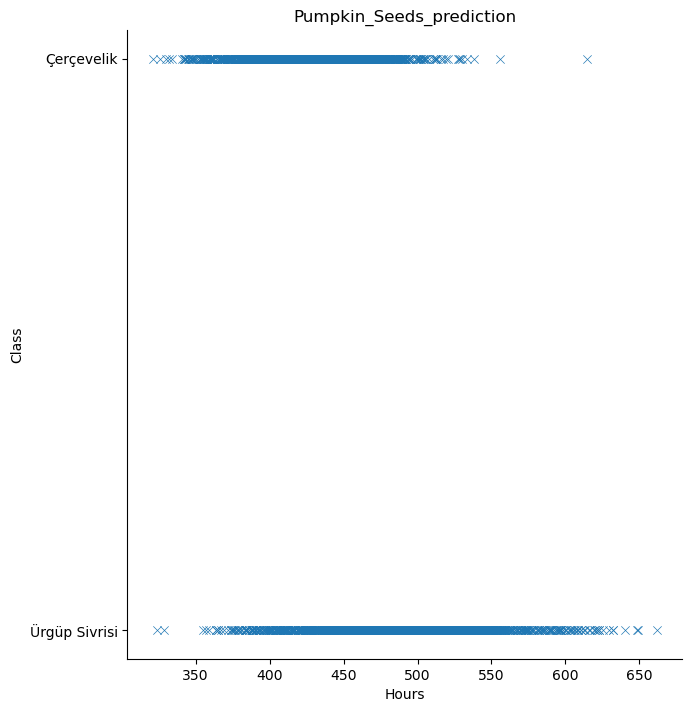

In [74]:
plt.figure(figsize=(3,3))
sns.pairplot(Pumpkin_Seeds , x_vars= ["Major_Axis_Length"] , y_vars= ["Class"] , size=7 , kind="scatter" , markers="x")
plt.xlabel("Hours")
plt.ylabel("Class")
plt.title("Pumpkin_Seeds_prediction")
plt.show()

# Grid_Search

In [75]:
x = Pumpkin_Seeds.iloc[: , 0:12]
y = Pumpkin_Seeds.iloc[: , -1]

In [76]:
x

,Area,Perimeter,Major_Axis_Length,Minor_Axis_Length,Convex_Area,Equiv_Diameter,Eccentricity,Solidity,Extent,Roundness,Aspect_Ration,Compactness
0,56276,888.242,326.1485,220.2388,56831,267.6805,0.7376,0.9902,0.7453,0.8963,1.4809,0.8207
1,76631,1068.146,417.1932,234.2289,77280,312.3614,0.8275,0.9916,0.7151,0.8440,1.7811,0.7487
2,71623,1082.987,435.8328,211.0457,72663,301.9822,0.8749,0.9857,0.7400,0.7674,2.0651,0.6929
3,66458,992.051,381.5638,222.5322,67118,290.8899,0.8123,0.9902,0.7396,0.8486,1.7146,0.7624
4,66107,998.146,383.8883,220.4545,67117,290.1207,0.8187,0.9850,0.6752,0.8338,1.7413,0.7557
...,...,...,...,...,...,...,...,...,...,...,...,...
2495,79637,1224.710,533.1513,190.4367,80381,318.4289,0.9340,0.9907,0.4888,0.6672,2.7996,0.5973
2496,69647,1084.318,462.9416,191.8210,70216,297.7874,0.9101,0.9919,0.6002,0.7444,2.4134,0.6433
2497,87994,1210.314,507.2200,222.1872,88702,334.7199,0.8990,0.9920,0.7643,0.7549,2.2828,0.6599
2498,80011,1182.947,501.9065,204.7531,80902,319.1758,0.9130,0.9890,0.7374,0.7185,2.4513,0.6359


In [77]:
y

0          Çerçevelik
1          Çerçevelik
2          Çerçevelik
3          Çerçevelik
4          Çerçevelik
            ...      
2495    Ürgüp Sivrisi
2496    Ürgüp Sivrisi
2497    Ürgüp Sivrisi
2498    Ürgüp Sivrisi
2499    Ürgüp Sivrisi
Name: Class, Length: 2500, dtype: object

In [78]:
x_train,x_test,y_train,y_test = train_test_split(x , y , test_size = 0.3 , random_state=42)

In [82]:
# define hyperparameters

my_params_grid={
    'C':[0.1,1,10],
    'kernel':['linear' , 'rbf'],
    'gamma':['scale' , 'auto']
    
}

In [83]:
model = SVC()

In [84]:
grid_search = GridSearchCV(
     estimator=model,
     param_grid=my_params_grid,
     scoring='accuracy',
     cv=5,
     n_jobs=-1             # run on gpu = -1 , run on cpu = 1
)

grid_search.fit(x_train , y_train)

GridSearchCV(cv=5, estimator=SVC(), n_jobs=-1,
             param_grid={'C': [0.1, 1, 10], 'gamma': ['scale', 'auto'],
                         'kernel': ['linear', 'rbf']},
             scoring='accuracy')

In [87]:
pd.DataFrame(grid_search.cv_results_)[['params' , 'mean_test_score' ,  'std_test_score']]

,params,mean_test_score,std_test_score
0,"{'C': 0.1, 'gamma': 'scale', 'kernel': 'linear'}",0.876571,0.013690
1,"{'C': 0.1, 'gamma': 'scale', 'kernel': 'rbf'}",0.582857,0.019124
2,"{'C': 0.1, 'gamma': 'auto', 'kernel': 'linear'}",0.876571,0.013690
3,"{'C': 0.1, 'gamma': 'auto', 'kernel': 'rbf'}",0.520000,0.000000
4,"{'C': 1, 'gamma': 'scale', 'kernel': 'linear'}",0.877714,0.012701
5,"{'C': 1, 'gamma': 'scale', 'kernel': 'rbf'}",0.582857,0.020682
6,"{'C': 1, 'gamma': 'auto', 'kernel': 'linear'}",0.877714,0.012701
7,"{'C': 1, 'gamma': 'auto', 'kernel': 'rbf'}",0.520000,0.000000
8,"{'C': 10, 'gamma': 'scale', 'kernel': 'linear'}",0.872571,0.015918
9,"{'C': 10, 'gamma': 'scale', 'kernel': 'rbf'}",0.598286,0.016423


In [88]:
grid_search.best_params_

{'C': 1, 'gamma': 'scale', 'kernel': 'linear'}

In [91]:
model=SVC(C=1 , gamma = 'scale' , kernel = 'linear')
model = model.fit(x_train , y_train)

In [92]:
y_pred = model.predict(x_test)
accuracy_score(y_test , y_pred)

0.86

# Random Search

In [93]:
x = Pumpkin_Seeds.iloc[: , 0:12]
y = Pumpkin_Seeds.iloc[: , -1]

In [94]:
x

,Area,Perimeter,Major_Axis_Length,Minor_Axis_Length,Convex_Area,Equiv_Diameter,Eccentricity,Solidity,Extent,Roundness,Aspect_Ration,Compactness
0,56276,888.242,326.1485,220.2388,56831,267.6805,0.7376,0.9902,0.7453,0.8963,1.4809,0.8207
1,76631,1068.146,417.1932,234.2289,77280,312.3614,0.8275,0.9916,0.7151,0.8440,1.7811,0.7487
2,71623,1082.987,435.8328,211.0457,72663,301.9822,0.8749,0.9857,0.7400,0.7674,2.0651,0.6929
3,66458,992.051,381.5638,222.5322,67118,290.8899,0.8123,0.9902,0.7396,0.8486,1.7146,0.7624
4,66107,998.146,383.8883,220.4545,67117,290.1207,0.8187,0.9850,0.6752,0.8338,1.7413,0.7557
...,...,...,...,...,...,...,...,...,...,...,...,...
2495,79637,1224.710,533.1513,190.4367,80381,318.4289,0.9340,0.9907,0.4888,0.6672,2.7996,0.5973
2496,69647,1084.318,462.9416,191.8210,70216,297.7874,0.9101,0.9919,0.6002,0.7444,2.4134,0.6433
2497,87994,1210.314,507.2200,222.1872,88702,334.7199,0.8990,0.9920,0.7643,0.7549,2.2828,0.6599
2498,80011,1182.947,501.9065,204.7531,80902,319.1758,0.9130,0.9890,0.7374,0.7185,2.4513,0.6359


In [95]:
y

0          Çerçevelik
1          Çerçevelik
2          Çerçevelik
3          Çerçevelik
4          Çerçevelik
            ...      
2495    Ürgüp Sivrisi
2496    Ürgüp Sivrisi
2497    Ürgüp Sivrisi
2498    Ürgüp Sivrisi
2499    Ürgüp Sivrisi
Name: Class, Length: 2500, dtype: object

In [100]:
x_train,x_test,y_train,y_test = train_test_split(x , y , test_size = 0.3 , random_state=42)

In [101]:
# define hyperparameters

my_params_distribution={
    'C':[0.1,1,10],
    'kernel':['linear' , 'rbf'],
    'gamma':['scale' , 'auto']
    
}

In [106]:
model = SVC()

In [111]:
random_search = RandomizedSearchCV(
     estimator=model,
     param_distributions=my_params_distribution,
     scoring='accuracy',
     cv=5,
     n_jobs=-1,             # run on gpu = -1 , run on cpu = 1
     n_iter=10
)

random_search.fit(x_train , y_train)

RandomizedSearchCV(cv=5, estimator=SVC(C=1, kernel='linear'), n_jobs=-1,
                   param_distributions={'C': [0.1, 1, 10],
                                        'gamma': ['scale', 'auto'],
                                        'kernel': ['linear', 'rbf']},
                   scoring='accuracy')

In [112]:
random_search.best_params_

{'kernel': 'linear', 'gamma': 'auto', 'C': 1}

In [113]:
model=SVC(C=1 , gamma = 'scale' , kernel = 'linear')
model = model.fit(x_train , y_train)

In [114]:
y_pred = model.predict(x_test)
accuracy_score(y_test , y_pred)

0.86